In [1]:
%load_ext autoreload
%autoreload 2

# Imports

In [2]:
import os
import sys

notebook_dir = os.path.dirname(os.path.abspath('__file__'))

project_root = os.path.abspath(os.path.join(notebook_dir, '..'))

if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

from src.utils.preprocessors import read_all_files,index_df,preprocess_context_data,normalize_tick
from src.utils.transformers import *
from src.utils.plotters import *
from src.utils.constants import *

# File Preparation

In [4]:
dfs_in_use = ["matches","rounds","player_frames"]
dfs = read_all_files(dfs_in_use,path="../src/esta/parsed/")
dfs = index_df(dfs,include=dfs_in_use[1:],index_by=["match_id","round_num"])
dfs = preprocess_context_data(dfs)
dfs = normalize_tick(dfs,include=dfs_in_use[1:])

Indexed DataFrame 'rounds' by ['match_id', 'round_num'].
Indexed DataFrame 'player_frames' by ['match_id', 'round_num'].


In [5]:
with open("../.awpy/maps/map-data.json", "r") as f:
    all_map_data = json.load(f)

In [6]:
matches_df = dfs["matches"]

In [7]:
selected_map = 'de_mirage'
map_data = all_map_data[selected_map]
selected_matches = matches_df[matches_df.map_name == selected_map]
display(selected_matches.head())
selected_match = selected_matches.iloc[0]
selected_round = 5
sel_idx = (selected_match.match_id,selected_round)

,client_name,map_name,tick_rate,playback_ticks,playback_frames_count,parsed_to_frame_idx,match_id,demo_id,competition_name,hltv_url,match_date,match_name
0,GOTV Demo,de_mirage,127,343251,342767,342784,0839a031-0e2c-4c03-b4bc-b5ba05fe669a,01746483-b3bd-4e4b-a2f2-0de97b17600d,PGL Major Antwerp 2022,https://www.hltv.org/matches/2356160/heroic-vs...,1652781600000,heroic-vs-vitality-pgl-major-antwerp-2022
0,GOTV Demo,de_mirage,127,471790,471564,471581,0a075b4d-576e-46f2-b944-fe9542faee54,04f0fb8f-a4d7-497c-857e-316300fadee3,IEM Katowice 2022,https://www.hltv.org/matches/2354381/furia-vs-...,1645124400000,furia-vs-astralis-iem-katowice-2022
0,GOTV Demo,de_mirage,127,426251,425998,426016,a98ffca7-e968-4a54-9e8f-22f101c2502b,022866a3-090e-42eb-ab8e-aa553a575ada,IEM Katowice 2021,https://www.hltv.org/matches/2346573/faze-vs-f...,1613905200000,faze-vs-furia-iem-katowice-2021
0,GOTV Demo,de_mirage,127,441259,440692,440707,a56115fd-a0ba-4eea-a618-91fd6c57177c,015f7c8d-2bc0-4d83-88e7-60648d2b221c,BLAST Premier Fall Showdown 2021,https://www.hltv.org/matches/2351973/heroic-vs...,1634034600000,heroic-vs-poggerz-blast-premier-fall-showdown-...
0,GOTV Demo,de_mirage,127,493224,492014,492029,f218743d-5e8b-436e-91bd-b7b3664c56c3,0418eb19-853e-4b56-955c-d3eedf2b7e12,BLAST Premier Spring Final 2021,https://www.hltv.org/matches/2349173/natus-vin...,1623853200000,natus-vincere-vs-faze-blast-premier-spring-fin...


# Viz

In [8]:
from src.utils.plotters import plot_loc_img_unicode

/tmp/nix-shell.2I4I3P/ipykernel_17558/2358143303.py:2: PerformanceWarning: indexing past lexsort depth may impact performance.
  dfs["player_frames"].loc[sel_idx])


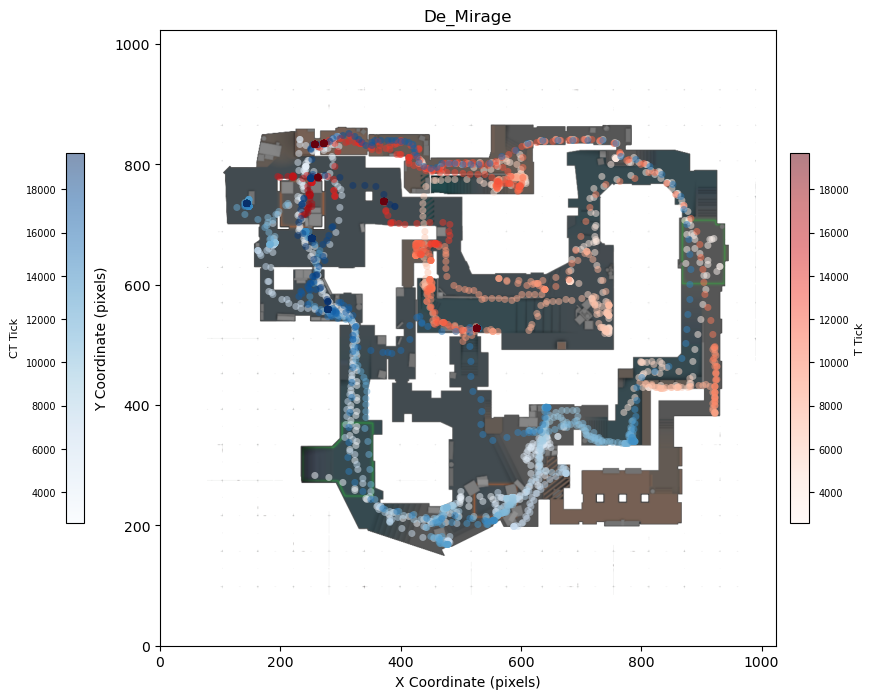

In [9]:
transformed_loc = transform_coord(map_data,
                                  dfs["player_frames"].loc[sel_idx])

img_loc_fig,img_loc_ax =  plot_map(selected_map, (10, 8),path="../.awpy/maps/")

loc_fig, loc_ax = plot_loc_img_unicode(transformed_loc, 
                                  gradient_by="tick",
                                  size=5,
                                  color_by="side",
                                  color_dict=side_color,
                                  default_marker="$\u2B24$",
                                  fig=img_loc_fig, 
                                  ax=img_loc_ax)

# PCA

In [32]:
from src.utils.pca import *

In [33]:
tf_loc = transformed_loc[["tick","side","steam_id","x","y"]]

In [34]:
sampling_rate = 20
all_ticks = sorted(tf_loc['tick'].unique())
all_ticks = np.array(all_ticks[::sampling_rate])

In [35]:
norm = plt.Normalize(vmin=all_ticks.min(), vmax=all_ticks.max())

In [36]:
side_df = pd.DataFrame()
side = "CT"
raw_loc_df = tf_loc[tf_loc.side == side].reset_index().drop(["match_id","round_num"],axis=1)
player_encode = {k:f"{p}" for p,k in enumerate(sorted(raw_loc_df.steam_id.unique()),start=1)}

index = []
for i in range(1,len(raw_loc_df.steam_id.unique())+1):
    index.append(f"p{i}x")
    index.append(f"p{i}y")
for tick in all_ticks:
    p_coords= list(raw_loc_df[raw_loc_df.tick == tick].sort_values("steam_id")[["x","y"]].values.reshape(1,-1)[0])
    side_df.loc[tick,index] = p_coords

side_df.index.set_names(["tick"],inplace=True)
print(side_df.shape)
display(side_df.head())

(14, 10)


,p1x,p1y,p2x,p2y,p3x,p3y,p4x,p4y,p5x,p5y
tick,,,,,,,,,,
2594,315.411591,327.957642,324.543274,310.074585,326.456848,341.275879,257.403259,284.338928,324.306793,263.07251
3874,241.059494,789.877625,238.636932,767.418884,242.450195,798.824585,557.834473,238.60376,629.839966,300.119629
5154,295.461487,765.940796,229.322067,749.337402,319.29483,443.68512,623.06604,325.595642,638.28241,336.293884
6434,320.826233,483.820679,299.042084,552.910522,478.270599,175.975952,587.728333,200.604309,571.80957,246.05188
7714,385.345093,211.419922,188.826706,669.419922,438.322662,200.505859,669.205872,295.732544,612.741821,258.437256


In [37]:
temporal_pca_results = temporal_pca(side_df,10,5,scale_factor=128)
test_result = temporal_pca_results["window_1"]

In [38]:
test_result

{'start': 2594,
 'end': 19244,
 'pca': PCA(n_components=5),
 'scaler': StandardScaler(),
 'pca_result':          PC1       PC2       PC3       PC4       PC5
 0  -0.733366  4.639331 -0.630701 -0.618948  0.356291
 1   1.162747  0.654447  2.947466  1.290150  0.135296
 2   0.105673  0.020948  1.765736  0.404249 -0.352565
 3  -2.237306  1.778367  0.695587 -0.624012 -0.279315
 4  -2.295519  0.015835 -0.547583  0.458554 -0.372463
 5  -2.634370 -0.544100 -1.487131  0.833979  0.200764
 6  -3.076531 -1.032841 -1.044703  0.950949  0.220651
 7  -1.459320 -1.376129 -0.198084 -0.368097 -0.113307
 8  -0.909952 -1.503098  0.592928 -1.158567 -0.331648
 9  -0.504495 -1.700646  0.878781 -1.288211  0.340327
 10  2.379263 -0.953047 -0.045060 -0.115204  0.912679
 11  3.120890 -0.179597 -0.652275  0.046175  0.133264
 12  3.627405  0.079664 -1.230702  0.105300 -0.447656
 13  3.454880  0.100866 -1.044259  0.083683 -0.402319,
 'components':           p1x       p1y       p2x       p2y       p3x       p3y       p

PC3
PC1
PC1
PC1
PC1


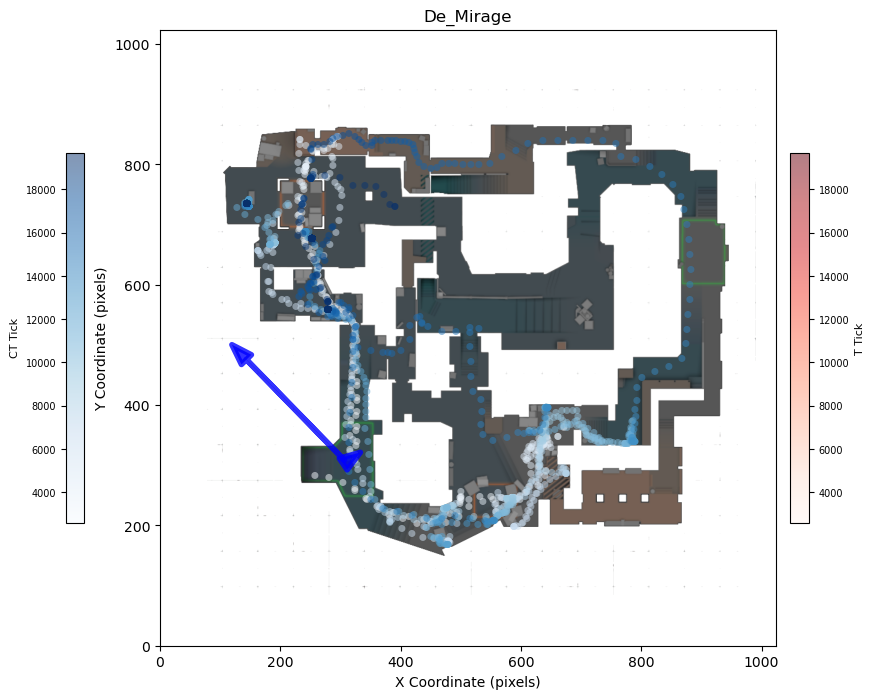

In [39]:
from matplotlib.patches import FancyArrowPatch

vectors = test_result["pc_vectors"].values()
img_loc_fig,img_loc_ax =  plot_map(selected_map, (10, 8),path="../.awpy/maps/")
loc_fig, loc_ax = plot_loc_img_unicode(tf_loc[tf_loc.side == "CT"], 
                                  gradient_by="tick",
                                  size=5,
                                  color_by="side",
                                  color_dict=side_color,
                                  default_marker="$\u2B24$",
                                  fig=img_loc_fig, 
                                  ax=img_loc_ax)

for vector in vectors:
    arrow = FancyArrowPatch(vector['start_pos'],
                            vector['end_pos'],
                            arrowstyle='simple,head_width=10,head_length=15', # Larger arrow head
                            alpha=0.8,
                            color="blue",
                            lw=4, # Line width
                            zorder=10) # Ensure arrows are on top
    img_loc_ax.add_patch(arrow)

for player,pc in inverse_pc_groups(test_result["pc_groups"]).items():
    print(pc)
    p_coord_cols = [player+"x",player+"y"]
    psx,psy = side_df.loc[test_result["start"],p_coord_cols]
    pdx,pdy = test_result["components"].loc[pc,p_coord_cols] 
    # img_loc_ax = plt.quiver(psx,psy,pdx,pdy,zorder=20)


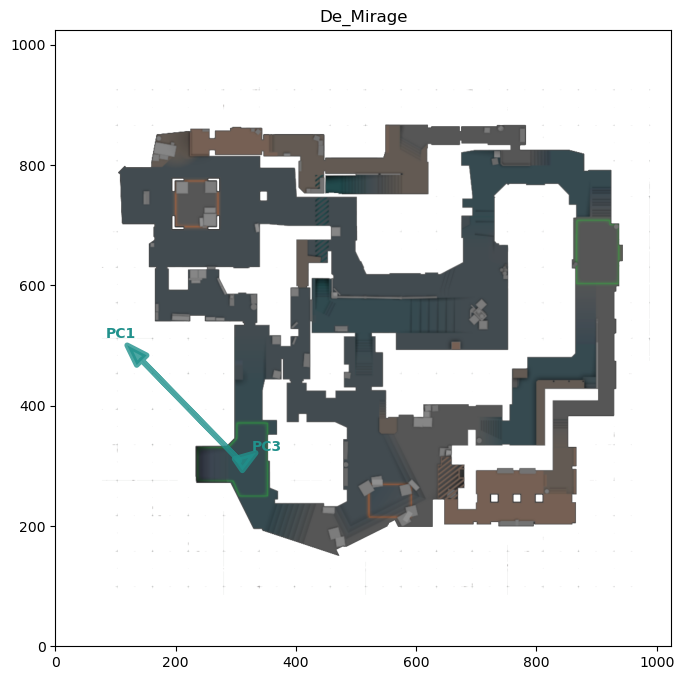

In [40]:
img_loc_fig,img_loc_ax =  plot_map(selected_map, (10, 8),path="../.awpy/maps/")
for window in temporal_pca_results.values():
    for pc,vector in window["pc_vectors"].items():
        color = plt.get_cmap("viridis")(norm(vector["tick"]))
        arrow = FancyArrowPatch(vector['start_pos'],
                            vector['end_pos'],
                            arrowstyle='simple,head_width=10,head_length=15', # Larger arrow head
                            alpha=0.8,
                            color=color,
                            lw=4, # Line width
                            zorder=10) # Ensure arrows are on top
        img_loc_ax.add_patch(arrow)

        
        vec_dx = vector["end_pos"][0] -vector["start_pos"][0]
        vec_dy = vector["end_pos"][1] -vector["start_pos"][1]
        
        # Small offset factor from the end of the arrow
        text_offset_factor = 15 
        
        # Adjust offset based on direction of the vector
        # This tries to place text slightly to the "outside" or "ahead" of the arrow
        text_x_offset = text_offset_factor * (1 if vec_dx >= 0 else -1)
        text_y_offset = text_offset_factor * (1 if vec_dy >= 0 else -1)
    
        # If the vector is mostly horizontal, adjust y-offset more. If vertical, adjust x-offset more.
        if abs(vec_dx) > abs(vec_dy): # More horizontal
            text_y_offset = text_offset_factor * (1 if vec_dy >= 0 else -1) * 0.5 # Less y-offset
        else: # More vertical
            text_x_offset = text_offset_factor * (1 if vec_dx >= 0 else -1) * 0.5 # Less x-offset
    
    
        img_loc_ax.text(vector["end_pos"][0] + text_x_offset,
                        vector['end_pos'][1]+ text_y_offset,
                        f'{pc}', # Use the 'pc_name' from your vector dictionary
                        color=color, # Use the same color as the arrow
                        fontsize=10, # Adjust font size as needed
                        weight='bold',
                        ha='center', va='center', # Center alignment relative to the text point
                        zorder=11) # Ensure text is above arrows

In [41]:
chained_vecs = chain_pc_vectors(temporal_pca_results)

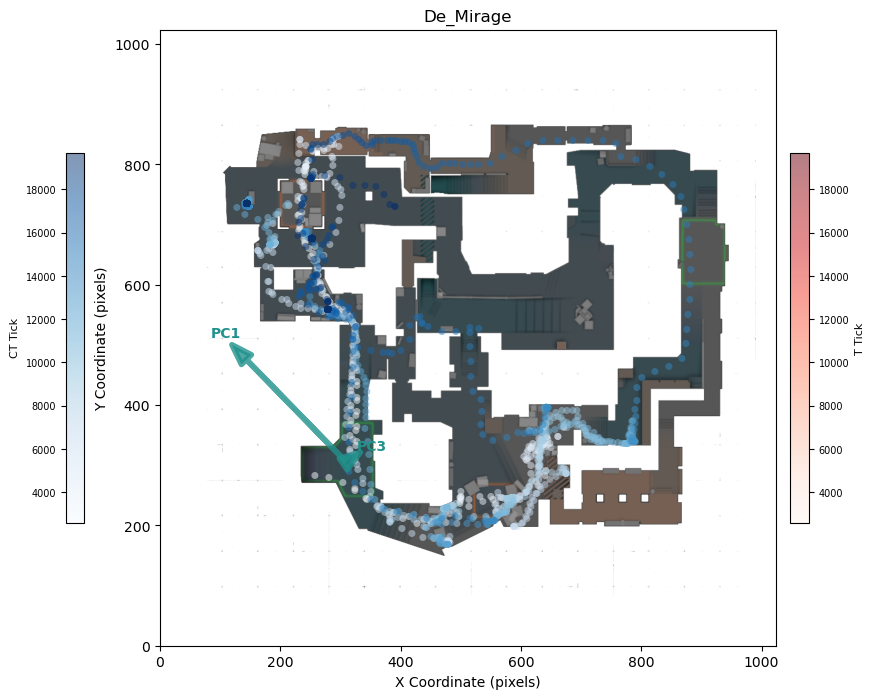

In [42]:
img_loc_fig,img_loc_ax =  plot_map(selected_map, (10, 8),path="../.awpy/maps/")
loc_fig, loc_ax = plot_loc_img_unicode(tf_loc[tf_loc.side == "CT"], 
                                  gradient_by="tick",
                                  size=5,
                                  color_by="side",
                                  color_dict=side_color,
                                  default_marker="$\u2B24$",
                                  fig=img_loc_fig, 
                                  ax=img_loc_ax)

for vector in chained_vecs[:]:
    color = plt.get_cmap("viridis")(norm(vector["tick"]))
    arrow = FancyArrowPatch(vector['start_pos'],
                            vector['end_pos'],
                            arrowstyle='simple,head_width=10,head_length=15', # Larger arrow head
                            alpha=0.8,
                            color=color,
                            lw=4, # Line width
                            zorder=10) # Ensure arrows are on top
    img_loc_ax.add_patch(arrow)

    vec_dx = vector["end_pos"][0] -vector["start_pos"][0]
    vec_dy = vector["end_pos"][1] -vector["start_pos"][1]
    
    # Small offset factor from the end of the arrow
    text_offset_factor = 15 
    
    # Adjust offset based on direction of the vector
    # This tries to place text slightly to the "outside" or "ahead" of the arrow
    text_x_offset = text_offset_factor * (1 if vec_dx >= 0 else -1)
    text_y_offset = text_offset_factor * (1 if vec_dy >= 0 else -1)

    # If the vector is mostly horizontal, adjust y-offset more. If vertical, adjust x-offset more.
    if abs(vec_dx) > abs(vec_dy): # More horizontal
        text_y_offset = text_offset_factor * (1 if vec_dy >= 0 else -1) * 0.5 # Less y-offset
    else: # More vertical
        text_x_offset = text_offset_factor * (1 if vec_dx >= 0 else -1) * 0.5 # Less x-offset


    img_loc_ax.text(vector["end_pos"][0] + text_x_offset,
                    vector['end_pos'][1]+ text_y_offset,
                    f'{vector["name"]}', # Use the 'pc_name' from your vector dictionary
                    color=color, # Use the same color as the arrow
                    fontsize=10, # Adjust font size as needed
                    weight='bold',
                    ha='center', va='center', # Center alignment relative to the text point
                    zorder=11) # Ensure text is above arrows